In [8]:
import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt
import csv
from scipy import stats
# Predicted crater dimensions based on Maxwell z model
# Given ___, expect _____

# constants
g = 1.62 # m/s/s acceleration due to gravity on the moon
k = 5 # falls between .0045 and .0055 depending on crater material and explosive type & placement
z = 2.7071 # this value of z conserves vertical momentum. in practice, z falls between 2 and 4   
v = 10000 # 10 km/s velocity

# display constants 
print("")
print("\033[1mConstants \033[0m")
print(f"""g = {g}m/s/s
k = {k}""")


Constants 
g = 1.62m/s/s
k = 5


   impactor    crater  maximum excavation
0       1.0  0.181822            0.681834
1       3.5  0.523471            1.963017
2       6.0  0.825052            3.093946
3       8.5  1.107046            4.151424
4      11.0  1.376203            5.160760
5      13.5  1.635902            6.134632
6      16.0  1.888165            7.080618
7      18.5  2.134330            8.003738
cd r2: 1.0
med r2: 1.0
sim coefficients: [0.68347578 2.93240028]
sim r2: 0.7560768059974936
expected sim self: 3.017834757834758, 3.274138176638177, 4.641089743589744, 6.349779202279201, 9.767158119658118, 
sim vs cd r2: 0.7560768059974936
expected sim cd: 0.14599889342167155, 0.18741447952922213, 0.40829760543615845, 0.6844015128198289, 1.2366093275871697, 
sim vs cd r2: 0.7560768059974937
expected sim hexc: 1.0949917006625378, 1.4056085964691671, 3.06223204077119, 5.133011346148718, 9.274569956903775, 
C.D. Fit Coefficients: [0.11044156 0.1321937 ]
M.E.D. Fit Coefficients: [0.82831172 0.99145274]


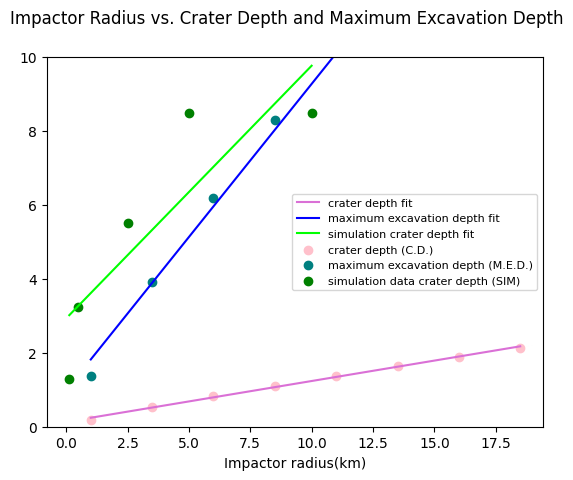

In [9]:
# output crater depth and excavation depth given impactor size

# set density constant
density = .00325 # kg/cm^3

# impactor radii in km
iradii = np.arange(1, 20, 2.5)

# preliminary calculations

# final transient crater radii function using equation #1 (eq 12 in maxwell 1977)
def iradius_to_cradius(r, d, g, k, z, v): # radius, density, gravity, k constant, z constant, velocity
    # d in kg/cm^3; r in km; g in m/s/s; v in m/s
    r_cm = r * 100000 # put radius in cm
    mass = (4/3)*(math.pi)*(r_cm**3)*d
    ke = (1/2)*mass*(v**2) # kinetic energy
    return (k*(4*z*(z - 2)*((ke*2.39006e-10)**(2*z/3))/g)**(1/(2*z + 1)))/1000 # crater radius

def iradius_to_cdepth(ir, d, g, k, z, v): 
    d = 2*iradius_to_cradius(ir, d, g, k, z, v) # crater diameter
    return 0.01 * d

def iradius_to_h_exc(ir, d, g, k, z, v):
    d = 2*iradius_to_cradius(ir, d, g, k, z, v) # crater diameter
    return 0.075*d

# calculate data to go in the csv
# crater depth function
cdepths = []
for r in iradii:
    cdepths.append(iradius_to_cdepth(r, density, g, k, z, v))

h_excs = []
for i in iradii:
    h_excs.append(iradius_to_h_exc(i, density, g, k, z, v))

# create list
data = [["impactor", "crater", "maximum excavation"]]
for i in range(len(iradii)):
    data.append([iradii[i], fcdepths[i], fh_excs[i]])

# Simulation data
sim_r = [0.125, 0.5, 2.5, 5, 10]
sim_h = [1.3, 3.25, 5.5, 8.5, 8.5]

# create csv
with open('radius_depth_hexc.csv', 'w', newline='') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerows(data)

df = pd.read_csv('radius_depth_hexc.csv')
print(df.to_string()) 

# create linear fit for cd scatter plot
coefficientsd = np.polyfit(iradii, cdepths, 1)
f = np.poly1d(coefficientsd)
plt.plot(iradii, f(iradii), color="orchid", label="crater depth fit")

# r2 for crater depth
predicted_cd = []
for i in cdepths:
    predicted_cd.append(f(i))
cd_m, cd_b, cd_r, cd_p, cd_std_err = stats.linregress(cdepths,predicted_cd)
print(f"cd r2: {cd_r**2}")

# create linear fit for hexc scatter plot
coefficientshexc = np.polyfit(iradii, h_excs, 1)
h = np.poly1d(coefficientshexc)
plt.plot(iradii, h(iradii), color="blue", label="maximum excavation depth fit")

# r2 for max excavation depth
predicted_h_exc = []
for i in h_excs:
    predicted_h_exc.append(h(i))
h_exc_m, h_exc_b, h_exc_r, h_exc_p, h_exc_std_err = stats.linregress(h_excs,predicted_h_exc)
print(f"med r2: {h_exc_r**2}")

# create linear fit for simulation scatter plot
sim_coefficients = np.polyfit(sim_r, sim_h, 1)
j = np.poly1d(sim_coefficients)
plt.plot(sim_r, j(sim_r), color="lime", label="simulation crater depth fit")

# r2 for simulation crater depth vs self
ex_sim_self = []
for i in sim_r:
    ex_sim_self.append(j(i))
sim_m, sim_b, sim_r_val, sim_p, sim_std_err = stats.linregress(sim_h,ex_sim_self)
print(f"sim coefficients: {sim_coefficients}")
print(f"sim r2: {sim_r_val**2}")
print("expected sim self: ", end="")
for i in ex_sim_self:
    print(f"{i},", end=" ")
print("")

# r2 for simulation crater depth vs expected crater depth
ex_sim_cd = []
for i in sim_r:
    ex_sim_cd.append(f(i))
sim_cd_m, sim_cd_b, sim_cd_r, sim_cd_p, sim_cd_std_err = stats.linregress(sim_h,ex_sim_cd)
print(f"sim vs cd r2: {sim_cd_r**2}")
print("expected sim cd: ", end="")
for i in ex_sim_cd:
    print(f"{i},", end=" ")
print("")

# r2 for simulation crater depth vs expected max excavation depth
ex_sim_h_exc = []
for i in sim_r:
    ex_sim_h_exc.append(h(i))
sim_h_exc_m, sim_h_exc_b, sim_h_exc_r, sim_h_exc_p, sim_h_exc_std_err = stats.linregress(sim_h,ex_sim_h_exc)
print(f"sim vs cd r2: {sim_h_exc_r**2}")
print("expected sim hexc: ", end="")
for i in ex_sim_h_exc:
    print(f"{i},", end=" ")
print("")

# scatter plot
print(f"C.D. Fit Coefficients: {coefficientsd}\nM.E.D. Fit Coefficients: {coefficientshexc}")
plt.scatter(iradii, cdepths, color = "pink", label="crater depth (C.D.)")
plt.scatter(iradii, h_excs, color="teal", label="maximum excavation depth (M.E.D.)")
plt.scatter(sim_r, sim_h, color="green", label="simulation data crater depth (SIM)")
plt.legend(fontsize="8")
plt.suptitle("Impactor Radius vs. Crater Depth and Maximum Excavation Depth\n ")
plt.annotate(f"C.D. Fit Coefficients: {coefficientsd}\nM.E.D. Fit Coefficients: {coefficientshexc}\nSIM coefficients: {sim_coefficients}\nSIM r^2: {sim_r_val**2}", xy=(-0.5,32), fontsize="9")
plt.ylim(0, 10)
plt.xlabel("Impactor radius(km)")
plt.show()

sim vs self r2: 0.8919121595599839
actual sim cd: 1.3, 3.25, 5.5, 
expected sim cd: 1.9249201277955268, 2.507907348242811, 5.617172523961661, 
sim vs cd r2: 0.8919121595599842
expected cd: 0.750991438075543, 1.8803919502112452, 7.903861348268323, 
sim vs cd r2: 0.8919121595599839
expected hexc: 0.024303284079923163, 0.09721313631969232, 0.48606568159846114, 


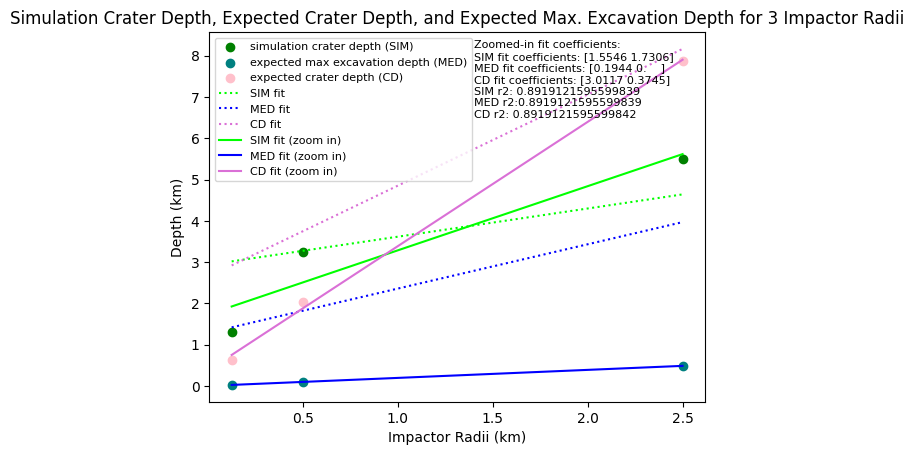

In [54]:
# zoom in on smaller crater sizes -- crater depth #

# simulation data
small_sim_r = [0.125, 0.5, 2.5]
small_sim_h = [1.3, 3.25, 5.5]

# expected crater depth
small_cd = []
for r in small_sim_r:
    small_cd.append(iradius_to_cdepth(r, density, g, k, z, v))

# expected max excavation depth
small_h_exc = []
for r in small_sim_r:
    small_h_exc.append(iradius_to_h_exc(r, density, g, k, z, v))

# create scatter plot #

# scatter
plt.scatter(small_sim_r, small_sim_h, color="green", label="simulation crater depth (SIM)")
plt.scatter(small_sim_r, small_h_exc, color="teal", label="expected max excavation depth (MED)")
plt.scatter(small_sim_r, small_cd, color="pink", label="expected crater depth (CD)")

# big fits
plt.plot(small_sim_r, j(small_sim_r), color="lime", label="SIM fit", linestyle=":")
plt.plot(small_sim_r, h(small_sim_r), color="blue", label="MED fit", linestyle=":")
plt.plot(small_sim_r, f(small_sim_r), color="orchid", label="CD fit", linestyle=":")

# small fits
small_sim_fit = np.polyfit(small_sim_r, small_sim_h, 1)
b = np.poly1d(small_sim_fit)
plt.plot(small_sim_r, b(small_sim_r), color="lime", label="SIM fit (zoom in)")

small_hexc_fit = np.polyfit(small_sim_r, small_h_exc, 1)
a = np.poly1d(small_hexc_fit)
plt.plot(small_sim_r, a(small_sim_r), color="blue", label="MED fit (zoom in)")

small_cd_fit = np.polyfit(small_sim_r, small_cd, 1)
c = np.poly1d(small_cd_fit)
plt.plot(small_sim_r, c(small_sim_r), color="orchid", label="CD fit (zoom in)")

# r2 values
ex_small_sim = []
for i in small_sim_r:
    ex_small_sim.append(np.polyval(b, i))
small_sim_m, small_sim_b, small_sim_r_val, small_sim_p, small_sim_std_err = stats.linregress(small_sim_h,ex_small_sim)
print(f"sim vs self r2: {small_sim_r_val**2}")
print("actual sim cd: ", end="")
for i in small_sim_h:
    print(f"{i},", end=" ")
print("")
print("expected sim cd: ", end="")
for i in ex_small_sim:
    print(f"{i},", end=" ")
print("")

ex_small_cd = []
for i in small_sim_r:
    ex_small_cd.append(np.polyval(c, i))
small_cd_m, small_cd_b, small_cd_r_val, small_cd_p, small_cd_std_err = stats.linregress(small_sim_h,ex_small_cd)
print(f"sim vs cd r2: {small_cd_r_val**2}")
print("expected cd: ", end="")
for i in ex_small_cd:
    print(f"{i},", end=" ")
print("")

ex_small_hexc = []
for i in small_sim_r:
    ex_small_hexc.append(np.polyval(a, i))
small_hexc_m, small_hexc_b, small_hexc_r_val, small_hexc_p, small_hexc_std_err = stats.linregress(small_sim_h,ex_small_hexc)
print(f"sim vs cd r2: {small_hexc_r_val**2}")
print("expected hexc: ", end="")
for i in ex_small_hexc:
    print(f"{i},", end=" ")
print("")

# label plot
plt.legend(fontsize="8")
plt.annotate(f"Zoomed-in fit coefficients:\nSIM fit coefficients: {np.round(small_sim_fit, decimals=4)}\nMED fit coefficients: {np.round(small_hexc_fit, decimals=4)}\nCD fit coefficients: {np.round(small_cd_fit, decimals=4)}\nSIM r2: {small_sim_r_val**2}\nMED r2:{small_hexc_r_val**2}\nCD r2: {small_cd_r_val**2}", (1.4, 6.5), fontsize="8")
plt.title("Simulation Crater Depth, Expected Crater Depth, and Expected Max. Excavation Depth for 3 Impactor Radii")
plt.xlabel("Impactor Radii (km)")
plt.ylabel("Depth (km)")
plt.show()

In [58]:
# complex craters



9.091114486620615
26.173556498033776
41.25260862085052
55.35232185620447
68.81013905749555
81.79509108793154
94.40823581064863
106.71650732173596


In [ ]:
# calculate relationship between ejecta thickness and distance


Text(0.5, 1.0, 'Ratio Between Maximum Excavation Depth and Crater Diameter as a Function of Crater Diameter')

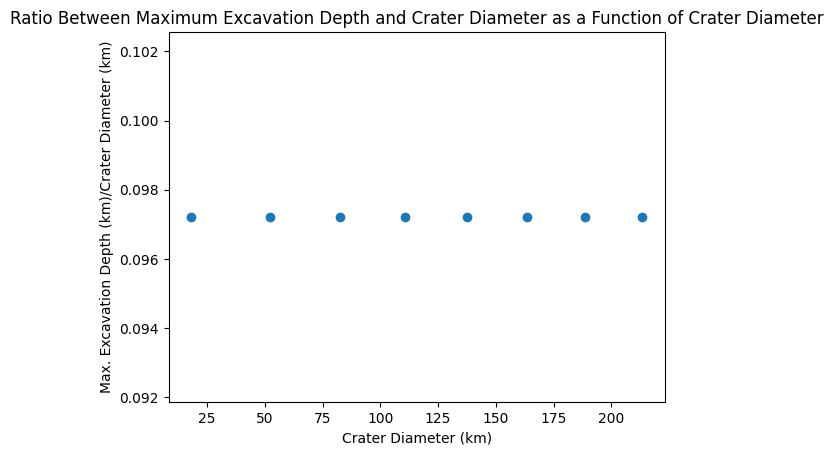

In [16]:
# ratio of maximum excavation depth to crater diameter vs. crater diameter

# maximum excavation depth/crater diameter
h_exc_cd_ratios = []
for i in range(len(cradii)):
    h_exc_cd_ratios.append(h_excs[i]/cdiameters[i])

# create scatter plot
plt.scatter(cdiameters, h_exc_cd_ratios)
plt.xlabel("Crater Diameter (km)")
plt.ylabel("Max. Excavation Depth (km)/Crater Diameter (km)")
plt.title("Ratio Between Maximum Excavation Depth and Crater Diameter as a Function of Crater Diameter")

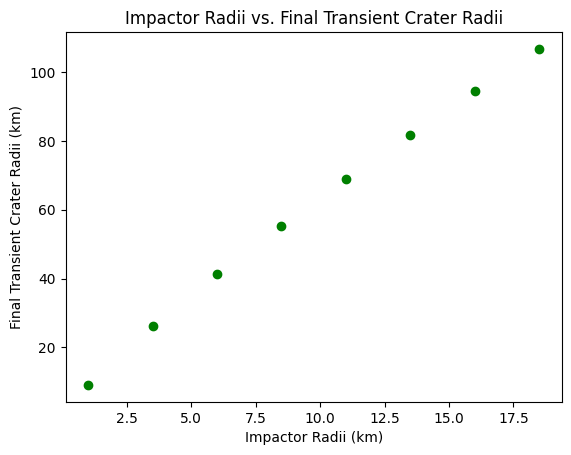

In [56]:
# impactor radii vs crater radii

# create scatter plot
plt.scatter(iradii, cradii, color="green")
plt.title("Impactor Radii vs. Final Transient Crater Radii")
plt.xlabel("Impactor Radii (km)")
plt.ylabel("Final Transient Crater Radii (km)")
plt.show()

Text(0.5, 1.0, 'Ratio Between Crater Depth and Crater Diameter as a Function of Crater Diameter')

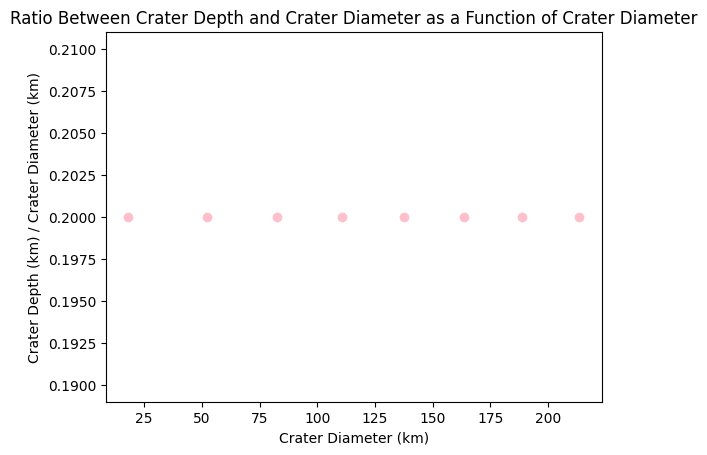

In [10]:
# ratio of crater depth to crater diameter vs. crater diameter

# crater depth/crater diameter
ch_cd_ratios = []
for i in range(len(cradii)):
    ch_cd_ratios.append(cdepths[i]/(2*cradii[i])) # diameter = 2*radii

# crater diameters
cdiameters = []
for i in range(len(cradii)):
    cdiameters.append(2*cradii[i])

# create scatter plot
plt.scatter(cdiameters, ch_cd_ratios, color="pink")
plt.xlabel("Crater Diameter (km)")
plt.ylabel("Crater Depth (km) / Crater Diameter (km)")
plt.title("Ratio Between Crater Depth and Crater Diameter as a Function of Crater Diameter")